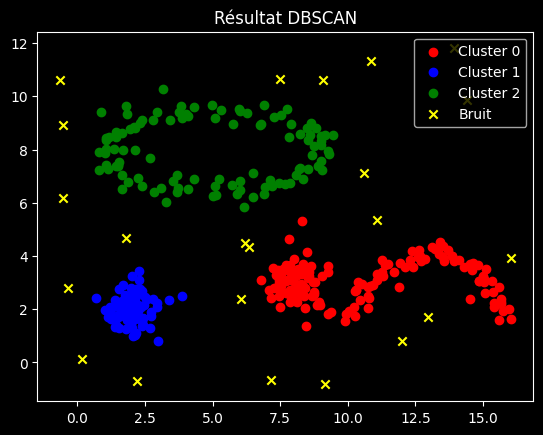

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dbscan_data.csv")  # importer le fichier de donnees
x = df['x'].values                   # x contient les valeurs de X
y = df['y'].values                   # y contient les valeurs de Y
pts = np.column_stack((x, y))        # concatener x et y pour avoir les points (x,y)

# fonction pour calculer la distance entre deux points
def distance(A, B):
    s = np.linalg.norm(A - B)  # formule de la distance euclidienne entre A et B
    return s                    # retourner la distance

# fonction pour obtenir la liste des voisins d'un point
def get_neighbors(pts, pt, epsilon):
    liste_voisins = []                          # liste vide au debut
    for i in range(len(pts)):                   # parcourir tous les points
        if distance(pt, pts[i]) < epsilon:      # si la distance est inferieure a epsilon
            liste_voisins.append(i)             # ajouter l'index du point dans la liste
    return liste_voisins                        # retourner la liste des voisins

epsilon = 1   # le rayon de recherche : on cherche les voisins dans ce rayon
minPts  = 5   # nombre minimum de voisins pour qu'un point soit un point central

#------------------------
# ALGO DBSCAN
#------------------------
labels  = [-1] * len(pts)    # -1 = bruit, chaque point commence comme bruit
visite  = [False] * len(pts) # False = pas encore visite, True = deja visite
cluster = 0                  # compteur de clusters, commence a 0

for i in range(len(pts)):    # parcourir tous les points un par un
    if visite[i]:            # si le point est deja visite
        continue             # passer au point suivant

    visite[i] = True                              # marquer le point comme visite
    voisins = get_neighbors(pts, pts[i], epsilon) # chercher ses voisins

    if len(voisins) < minPts:  # si pas assez de voisins
        labels[i] = -1         # le point est du bruit

    else:                      # sinon c'est un point central → creer un cluster
        labels[i] = cluster    # assigner le numero du cluster au point central
        j = 0                  # compteur pour parcourir la liste des voisins

        while j < len(voisins):              # tant qu'il reste des voisins a explorer
            v = voisins[j]                   # recuperer l'index du voisin actuel

            if not visite[v]:                # si ce voisin n'est pas encore visite
                visite[v] = True             # le marquer comme visite
                nouveaux_voisin = get_neighbors(pts, pts[v], epsilon)  # chercher ses voisins
                if len(nouveaux_voisin) >= minPts:  # si c'est aussi un point central
                    voisins += nouveaux_voisin       # ajouter ses voisins a explorer

            if labels[v] == -1:        # si le voisin n'appartient a aucun cluster
                labels[v] = cluster    # l'assigner au cluster actuel

            j += 1         # passer au voisin suivant

        cluster += 1       # tous les voisins explores → passer au cluster suivant

# --- Visualisation ---
labels = np.array(labels)  # convertir labels en tableau numpy pour la visualisation

couleurs = ['red', 'blue', 'green', 'orange', 'purple', 'pink']  # une couleur par cluster

for c in range(cluster):                        # parcourir chaque cluster
    points_cluster = pts[labels == c]           # recuperer les points de ce cluster
    plt.scatter(points_cluster[:, 0], points_cluster[:, 1],  # afficher les points
                color=couleurs[c % len(couleurs)],            # couleur du cluster
                label=f'Cluster {c}')                         # legende

points_bruit = pts[labels == -1]               # recuperer les points bruit
plt.scatter(points_bruit[:, 0], points_bruit[:, 1],  # afficher les points bruit
            color='yellow', marker='x', label='Bruit')       # en jaune avec une croix
plt.title("Résultat DBSCAN")
plt.legend()
plt.show()